### Importing Important Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Importing the dataset and viewing it

In [2]:
df = pd.read_excel('gamezone-orders-data.xlsx')

df.head()

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
0,2c06175e,0001328c3c220830,2020-12-24 00:00:00,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US
1,ee8e5bc2,0002af7a5c6100772,2020-10-01 00:00:00,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE
2,9eb4efe0,0002b8350e167074,2020-04-21 00:00:00,2020-02-16,Nintendo Switch,8d0d,151.20,website,direct,desktop,US
3,cac7cbaf,0006d06b98385729,2020-04-07 00:00:00,2020-04-04,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU
4,6b0230bc,00097279a2f46150,2020-11-24 00:00:00,2020-08-02,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR


In [3]:
df_region = pd.read_csv('region.csv')

In [4]:
df_region.head()

,COUNTRY_CODE,REGION
0,AD,EMEA
1,AE,EMEA
2,AG,NaN
3,AI,NaN
4,AL,EMEA


In [5]:
# Copies of the datasets

df2 = pd.read_excel('gamezone-orders-data.xlsx')

df2_region = pd.read_csv('region.csv')

### Understanding the data

In [6]:
df.columns

Index(['USER_ID', 'ORDER_ID', 'PURCHASE_TS', 'SHIP_TS', 'PRODUCT_NAME',
       'PRODUCT_ID', 'USD_PRICE', 'PURCHASE_PLATFORM', 'MARKETING_CHANNEL',
       'ACCOUNT_CREATION_METHOD', 'COUNTRY_CODE'],
      dtype='object')

In [7]:
df_region.columns

Index(['COUNTRY_CODE', 'REGION'], dtype='object')

In [8]:
df.shape

(21864, 11)

In [9]:
df_region.shape

(999, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21864 entries, 0 to 21863
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   USER_ID                  21864 non-null  object        
 1   ORDER_ID                 21864 non-null  object        
 2   PURCHASE_TS              21864 non-null  object        
 3   SHIP_TS                  21864 non-null  datetime64[ns]
 4   PRODUCT_NAME             21864 non-null  object        
 5   PRODUCT_ID               21864 non-null  object        
 6   USD_PRICE                21859 non-null  float64       
 7   PURCHASE_PLATFORM        21864 non-null  object        
 8   MARKETING_CHANNEL        21781 non-null  object        
 9   ACCOUNT_CREATION_METHOD  21781 non-null  object        
 10  COUNTRY_CODE             21826 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 1.8+ MB


In [11]:
df_region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   COUNTRY_CODE  191 non-null    object
 1   REGION        169 non-null    object
dtypes: object(2)
memory usage: 15.7+ KB


**Checking Missing Values**

In [12]:
df.isnull().sum()

USER_ID                     0
ORDER_ID                    0
PURCHASE_TS                 0
SHIP_TS                     0
PRODUCT_NAME                0
PRODUCT_ID                  0
USD_PRICE                   5
PURCHASE_PLATFORM           0
MARKETING_CHANNEL          83
ACCOUNT_CREATION_METHOD    83
COUNTRY_CODE               38
dtype: int64

In [13]:
df_region.isnull().sum()

COUNTRY_CODE    808
REGION          830
dtype: int64

**Checking Duplicates**

In [14]:
print(df.duplicated().sum())

35


In [15]:
print(df_region.duplicated().sum())

806


**Understanding Categorical Variables** 

In [16]:
df['PURCHASE_PLATFORM'].value_counts()

PURCHASE_PLATFORM
website       19783
mobile app     2081
Name: count, dtype: int64

In [17]:
df['MARKETING_CHANNEL'].value_counts()

MARKETING_CHANNEL
direct          17434
email            3256
affiliate         721
social media      323
unknown            47
Name: count, dtype: int64

In [18]:
df['ACCOUNT_CREATION_METHOD'].value_counts()

ACCOUNT_CREATION_METHOD
desktop    16458
mobile      4232
unknown      743
tablet       323
tv            25
Name: count, dtype: int64

In [19]:
df['COUNTRY_CODE'].value_counts()

COUNTRY_CODE
US    10294
GB     1808
CA      956
AU      893
DE      855
      ...  
NP        1
FJ        1
KN        1
BH        1
LC        1
Name: count, Length: 150, dtype: int64

In [20]:
df['PRODUCT_NAME'].unique()

array(['Nintendo Switch', 'Sony PlayStation 5 Bundle',
       '27in 4K gaming monitor', 'JBL Quantum 100 Gaming Headset',
       'Dell Gaming Mouse', 'Acer Nitro V Gaming Laptop',
       'Lenovo IdeaPad Gaming 3', 'Razer Pro Gaming Headset',
       '27inches 4k gaming monitor'], dtype=object)

In [21]:
df['COUNTRY_CODE'].unique()

array(['US', 'DE', 'AU', 'TR', 'PH', 'GB', 'BR', 'BE', 'FR', 'KR', 'ES',
       'UA', 'AT', 'IN', 'IL', 'PL', 'DK', 'AR', 'CH', 'CL', 'RO', 'VN',
       'JM', 'IT', 'BB', 'JP', 'NO', 'HU', 'CA', 'VE', 'NZ', 'CY', 'BO',
       'CO', 'NL', 'SE', 'KW', 'ZA', 'SI', 'RU', 'GR', 'LT', 'MX', 'TH',
       'UY', 'CZ', 'HK', 'EE', 'SG', 'KH', 'IE', 'IQ', 'FI', 'TZ', 'TW',
       nan, 'QA', 'PT', 'PE', 'MY', 'AE', 'LV', 'EG', 'CI', 'BS', 'IS',
       'CR', 'MT', 'MA', 'HT', 'SA', 'KE', 'JO', 'BG', 'GH', 'BD', 'TT',
       'LK', 'AD', 'SN', 'NG', 'PF', 'PK', 'LU', 'KZ', 'VI', 'SK', 'GT',
       'TN', 'GL', 'NI', 'DO', 'MV', 'KY', 'MN', 'BH', 'MC', 'LB', 'KN',
       'PR', 'HR', 'ZW', 'FJ', 'HN', 'PA', 'NP', 'UG', 'JE', 'BW', 'EC',
       'OM', 'MM', 'MU', 'PG', 'AL', 'BY', 'EU', 'DZ', 'ML', 'PS', 'SO',
       'SV', 'MK', 'RS', 'IM', 'VC', 'GU', 'MO', 'ZM', 'GE', 'AZ', 'BM',
       'AW', 'SL', 'CM', 'AO', 'BA', 'MP', 'AP', 'AI', 'ME', 'CN', 'ID',
       'VU', 'PY', 'BF', 'RE', 'MZ', 'MH', 'MD', 'LC

In [22]:
print(df['SHIP_TS'].min())
print(df['SHIP_TS'].max())

2018-10-18 00:00:00
2021-11-16 00:00:00


In [23]:
print(df['COUNTRY_CODE'].nunique())
print(df_region['COUNTRY_CODE'].nunique())

150
191


In [24]:
df_region['REGION'].value_counts()

REGION
EMEA             98
APAC             42
LATAM            22
North America     5
X.x               2
Name: count, dtype: int64

**Deleting Duplicates**

In [25]:
df.drop_duplicates(inplace = True)
df.shape

(21829, 11)

In [26]:
df_region.drop_duplicates(inplace = True)
print(df_region.shape)

(193, 2)


In [27]:
print(df['COUNTRY_CODE'].nunique())
print(df_region['COUNTRY_CODE'].nunique())

150
191


**Convert PURCHASE_TS to datetime dtype**

In [28]:
df['PURCHASE_TS'] = pd.to_datetime(df['PURCHASE_TS'], errors = 'coerce')

In [29]:
print(df['PURCHASE_TS'].dtype)
print(df['SHIP_TS'].dtype)

datetime64[ns]
datetime64[ns]


In [30]:
print(df['PURCHASE_TS'].isnull().sum())
print(df['SHIP_TS'].isnull().sum())

5
0


**Fill Missing Values in PURCHASE_TS column**

In [31]:
df[df['PURCHASE_TS'].isna()]

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
1047,a5298a4d,0dda212aaea69940,NaT,2019-07-08,JBL Quantum 100 Gaming Headset,ab0f,21.96,website,direct,desktop,FR
5846,a81bb521,4cd9ab100d971208,NaT,2021-01-11,Nintendo Switch,8d0d,120.26,website,direct,desktop,IE
11853,2fa9f33d,99d824517da22388,NaT,2019-04-11,JBL Quantum 100 Gaming Headset,ab0f,21.19,website,direct,mobile,JP
16163,b313cea5,c9e0aea0d9a75871,NaT,2019-05-18,JBL Quantum 100 Gaming Headset,ab0f,19.20,website,direct,desktop,US
20725,67f8050b,f4de38506b644875,NaT,2019-01-17,JBL Quantum 100 Gaming Headset,ab0f,25.69,website,direct,desktop,GB


In [32]:
df2.loc[[1047, 5846, 11853, 16163, 20725]]

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
1047,a5298a4d,0dda212aaea69940,,2019-07-08,JBL Quantum 100 Gaming Headset,ab0f,21.96,website,direct,desktop,FR
5846,a81bb521,4cd9ab100d971208,06-14-2019 13:62:38,2021-01-11,Nintendo Switch,8d0d,120.26,website,direct,desktop,IE
11853,2fa9f33d,99d824517da22388,06-14-2019 13:62:39,2019-04-11,JBL Quantum 100 Gaming Headset,ab0f,21.19,website,direct,mobile,JP
16163,b313cea5,c9e0aea0d9a75871,06-14-2019 13:62:34,2019-05-18,JBL Quantum 100 Gaming Headset,ab0f,19.20,website,direct,desktop,US
20725,67f8050b,f4de38506b644875,06-14-2019 13:62:41,2019-01-17,JBL Quantum 100 Gaming Headset,ab0f,25.69,website,direct,desktop,GB


In [33]:
df.loc[[5846, 11853, 16163, 20725], 'PURCHASE_TS'] = pd.to_datetime('2019-06-14')

In [34]:
df.loc[[1047, 5846, 11853, 16163, 20725]]

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
1047,a5298a4d,0dda212aaea69940,NaT,2019-07-08,JBL Quantum 100 Gaming Headset,ab0f,21.96,website,direct,desktop,FR
5846,a81bb521,4cd9ab100d971208,2019-06-14,2021-01-11,Nintendo Switch,8d0d,120.26,website,direct,desktop,IE
11853,2fa9f33d,99d824517da22388,2019-06-14,2019-04-11,JBL Quantum 100 Gaming Headset,ab0f,21.19,website,direct,mobile,JP
16163,b313cea5,c9e0aea0d9a75871,2019-06-14,2019-05-18,JBL Quantum 100 Gaming Headset,ab0f,19.20,website,direct,desktop,US
20725,67f8050b,f4de38506b644875,2019-06-14,2019-01-17,JBL Quantum 100 Gaming Headset,ab0f,25.69,website,direct,desktop,GB


In [35]:
print(df['PURCHASE_TS'].dtype)
print(df['SHIP_TS'].dtype)

datetime64[ns]
datetime64[ns]


**Add the Region Column**

In [36]:
df_region.isnull().sum()

COUNTRY_CODE     2
REGION          24
dtype: int64

In [37]:
df_region[df_region['COUNTRY_CODE'].isna()]

,COUNTRY_CODE,REGION
129,NaN,EMEA
192,NaN,NaN


In [38]:
mapping = dict(zip(df_region['COUNTRY_CODE'], df_region['REGION']))
df['REGION'] = df['COUNTRY_CODE'].map(mapping)

In [39]:
df.head(2)

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,NaN
1,ee8e5bc2,0002af7a5c6100772,2020-10-01,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE,EMEA


In [40]:
df.shape

(21829, 12)

**Fill Missing Values in USD_PRICE**

In [41]:
df[df['USD_PRICE'].isna()]

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION
1190,f2939b5c,0fa89eecc5d102514,2020-08-20,2020-05-26,Dell Gaming Mouse,0c5a,NaN,mobile app,email,desktop,GH,EMEA
13282,45913313,ab0b1a9c91a1197,2019-12-25,2019-12-28,JBL Quantum 100 Gaming Headset,2997,NaN,mobile app,email,mobile,KE,EMEA
14189,1c173578,b6a132d331c14466,2020-09-01,2020-09-04,Dell Gaming Mouse,f81e,NaN,mobile app,direct,desktop,KE,EMEA
20044,7c364c50,eee5663869153075,2020-07-11,2020-07-12,Dell Gaming Mouse,f81e,NaN,mobile app,email,mobile,VE,LATAM
20227,70565cdf,f063ed5ec8848400,2021-01-08,2021-01-10,Dell Gaming Mouse,f81e,NaN,mobile app,email,desktop,BO,LATAM


In [42]:
df[(df['PRODUCT_NAME'] == 'JBL Quantum 100 Gaming Headset') & (df['COUNTRY_CODE'] == 'KE')]

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION
7390,3bdcc7a8,614dca75a6d27251,2020-07-08,2020-07-10,JBL Quantum 100 Gaming Headset,ab0f,24.0,website,direct,desktop,KE,EMEA
13282,45913313,ab0b1a9c91a1197,2019-12-25,2019-12-28,JBL Quantum 100 Gaming Headset,2997,NaN,mobile app,email,mobile,KE,EMEA
20983,519c28e4,f78a69de1a536063,2020-05-05,2020-05-08,JBL Quantum 100 Gaming Headset,ab0f,24.0,website,direct,desktop,KE,EMEA


In [43]:
df.loc[14189, 'USD_PRICE'] = 49.98
df.loc[20044, 'USD_PRICE'] = 49.98
df.loc[13282, 'USD_PRICE'] = 24.0

**Change the PRODUCT_NAME of one product**

In [44]:
df['PRODUCT_NAME'].unique()

array(['Nintendo Switch', 'Sony PlayStation 5 Bundle',
       '27in 4K gaming monitor', 'JBL Quantum 100 Gaming Headset',
       'Dell Gaming Mouse', 'Acer Nitro V Gaming Laptop',
       'Lenovo IdeaPad Gaming 3', 'Razer Pro Gaming Headset',
       '27inches 4k gaming monitor'], dtype=object)

In [45]:
df['PRODUCT_NAME'] = df['PRODUCT_NAME'].replace(
    '27in 4K gaming monitor', '27inches 4k gaming monitor')

In [46]:
df['PRODUCT_NAME'].unique()

array(['Nintendo Switch', 'Sony PlayStation 5 Bundle',
       '27inches 4k gaming monitor', 'JBL Quantum 100 Gaming Headset',
       'Dell Gaming Mouse', 'Acer Nitro V Gaming Laptop',
       'Lenovo IdeaPad Gaming 3', 'Razer Pro Gaming Headset'],
      dtype=object)

In [47]:
df.loc[df['COUNTRY_CODE'] == 'US', 'REGION'] = 'US/Null'

In [48]:
df[df['COUNTRY_CODE'] == 'US']

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,US/Null
2,9eb4efe0,0002b8350e167074,2020-04-21,2020-02-16,Nintendo Switch,8d0d,151.20,website,direct,desktop,US,US/Null
9,a2eaa1d1,001620ea42468912,2019-11-01,2019-10-17,Nintendo Switch,e682,168.00,website,direct,desktop,US,US/Null
12,9933b602,002a0b04dd764807,2020-02-16,2019-12-08,Sony PlayStation 5 Bundle,54ed,1725.86,website,direct,desktop,US,US/Null
13,bbbaa7ff,002f0b22bb379479,2020-05-14,2020-03-24,Nintendo Switch,e682,168.00,website,direct,desktop,US,US/Null
...,...,...,...,...,...,...,...,...,...,...,...,...
21856,7908c639,ffeec4c209751749,2021-01-20,2021-01-23,Lenovo IdeaPad Gaming 3,04ac,599.00,website,direct,desktop,US,US/Null
21857,7908c639,ffeec4c209751750,2021-01-20,2021-01-23,Lenovo IdeaPad Gaming 3,04ac,599.00,website,direct,desktop,US,US/Null
21859,e432cf6f,fff0b6a1e9996384,2019-11-27,2019-11-29,Sony PlayStation 5 Bundle,54ed,1527.06,website,direct,desktop,US,US/Null
21860,f4f11c04,fff4592dc6d103535,2019-12-23,2019-12-26,27inches 4k gaming monitor,891b,467.88,website,direct,desktop,US,US/Null


#### Understanding the data again

In [49]:
df.shape

(21829, 12)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21829 entries, 0 to 21863
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   USER_ID                  21829 non-null  object        
 1   ORDER_ID                 21829 non-null  object        
 2   PURCHASE_TS              21828 non-null  datetime64[ns]
 3   SHIP_TS                  21829 non-null  datetime64[ns]
 4   PRODUCT_NAME             21829 non-null  object        
 5   PRODUCT_ID               21829 non-null  object        
 6   USD_PRICE                21827 non-null  float64       
 7   PURCHASE_PLATFORM        21829 non-null  object        
 8   MARKETING_CHANNEL        21746 non-null  object        
 9   ACCOUNT_CREATION_METHOD  21746 non-null  object        
 10  COUNTRY_CODE             21791 non-null  object        
 11  REGION                   21554 non-null  object        
dtypes: datetime64[ns](2), float64(1), obj

In [51]:
print(df.duplicated().sum())

0


In [52]:
df.isnull().sum()

USER_ID                      0
ORDER_ID                     0
PURCHASE_TS                  1
SHIP_TS                      0
PRODUCT_NAME                 0
PRODUCT_ID                   0
USD_PRICE                    2
PURCHASE_PLATFORM            0
MARKETING_CHANNEL           83
ACCOUNT_CREATION_METHOD     83
COUNTRY_CODE                38
REGION                     275
dtype: int64

In [53]:
df['USER_ID'].nunique()

19851

In [54]:
df['PRODUCT_NAME'].value_counts()

PRODUCT_NAME
Nintendo Switch                   10386
27inches 4k gaming monitor         4688
JBL Quantum 100 Gaming Headset     4296
Sony PlayStation 5 Bundle           977
Dell Gaming Mouse                   719
Lenovo IdeaPad Gaming 3             669
Acer Nitro V Gaming Laptop           87
Razer Pro Gaming Headset              7
Name: count, dtype: int64

In [55]:
df['PURCHASE_PLATFORM'].value_counts()

PURCHASE_PLATFORM
website       19748
mobile app     2081
Name: count, dtype: int64

In [56]:
df['MARKETING_CHANNEL'].value_counts()

MARKETING_CHANNEL
direct          17403
email            3256
affiliate         717
social media      323
unknown            47
Name: count, dtype: int64

In [57]:
df['ACCOUNT_CREATION_METHOD'].value_counts()

ACCOUNT_CREATION_METHOD
desktop    16434
mobile      4225
unknown      739
tablet       323
tv            25
Name: count, dtype: int64

In [58]:
df['REGION'].value_counts()

REGION
US/Null          10275
EMEA              6502
APAC              2573
LATAM             1241
North America      959
X.x                  4
Name: count, dtype: int64

### Revenue 

**Gross Merchandise Value**

In [59]:
gmv = df['USD_PRICE'].sum()
print(f'The GMV of the Gamezone Orders is {gmv:.2f}$')

The GMV of the Gamezone Orders is 6136872.19$


In [60]:
# GMV by Product
gmv_product = df.groupby('PRODUCT_NAME')['USD_PRICE'].agg(['count', 'sum']).reset_index()
gmv_product.sort_values(by = 'sum')

,PRODUCT_NAME,count,sum
6,Razer Pro Gaming Headset,7,884.23
2,Dell Gaming Mouse,717,36589.97
1,Acer Nitro V Gaming Laptop,87,65661.18
3,JBL Quantum 100 Gaming Headset,4296,96221.67
4,Lenovo IdeaPad Gaming 3,669,735506.56
7,Sony PlayStation 5 Bundle,977,1589243.85
5,Nintendo Switch,10386,1658717.65
0,27inches 4k gaming monitor,4688,1954047.08


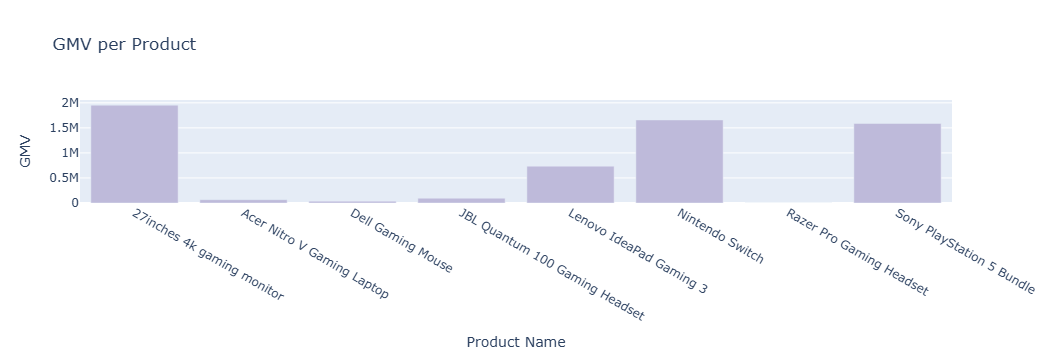

In [61]:
# GMV by Product graph
fig = px.bar(data_frame=gmv_product, x='PRODUCT_NAME', y='sum',
            labels={'PRODUCT_NAME' : 'Product Name', 'sum' : 'GMV'},
            title='GMV per Product',
            color_discrete_sequence=['#BEBADA'])
fig.update_layout(xaxis_tickangle = 30)
fig.show()

In [62]:
# GMV by Purchase Platform
gmv_pp = df.groupby('PURCHASE_PLATFORM')['USD_PRICE'].agg(['count', 'sum']).reset_index()
gmv_pp.sort_values(by = 'sum')

,PURCHASE_PLATFORM,count,sum
0,mobile app,2079,154066.03
1,website,19748,5982806.16


In [63]:
# GMV by Marketing channel
gmv_mc = df.groupby('MARKETING_CHANNEL')['USD_PRICE'].agg(['count', 'sum']).reset_index()
gmv_mc.sort_values(by = 'sum')

,MARKETING_CHANNEL,count,sum
4,unknown,47,12044.16
3,social media,323,69526.37
0,affiliate,717,220798.81
2,email,3254,611256.70
1,direct,17403,5197019.88


In [64]:
gmv_region = df.groupby('REGION')['USD_PRICE'].agg(['count', 'sum']).reset_index()
gmv_region.sort_values(by = 'sum')

,REGION,count,sum
5,X.x,4,936.26
3,North America,959,233950.02
2,LATAM,1240,335192.75
0,APAC,2573,740523.84
1,EMEA,6501,1819907.80
4,US/Null,10275,2947679.42


In [65]:
# Adding the QUARTER column to the dataset
df['QUARTER'] = df['PURCHASE_TS'].dt.to_period('Q')

In [66]:
df.head(2)

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION,QUARTER
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,US/Null,2020Q4
1,ee8e5bc2,0002af7a5c6100772,2020-10-01,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE,EMEA,2020Q4


In [67]:
# Quarterly Sales trend
qoq = df.groupby('QUARTER')['USD_PRICE'].sum().reset_index()

qoq

,QUARTER,USD_PRICE
0,2019Q1,296074.36
1,2019Q2,353236.27
2,2019Q3,416219.82
3,2019Q4,475415.09
4,2020Q1,583315.08
5,2020Q2,1021808.74
6,2020Q3,1176272.50
7,2020Q4,1276302.64
8,2021Q1,538205.73


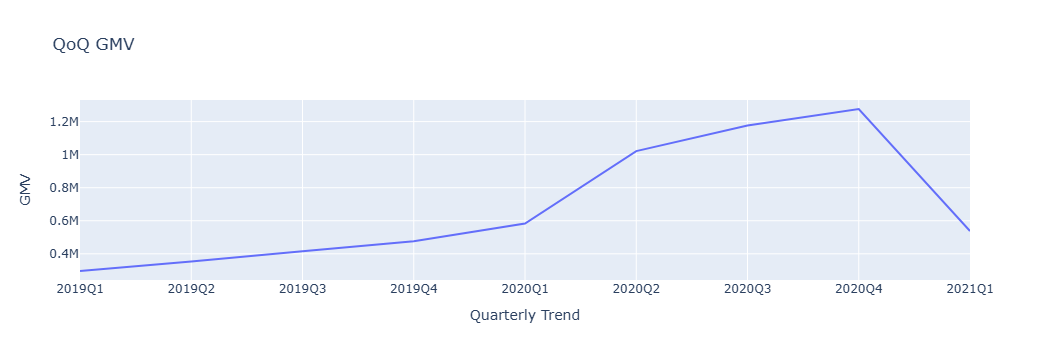

In [68]:
qoq['QUARTER'] = qoq['QUARTER'].astype(str)

fig = px.line(data_frame= qoq, x='QUARTER', y='USD_PRICE',
              labels= {'QUARTER':'Quarterly Trend', 'USD_PRICE' : 'GMV'},
              title= 'QoQ GMV')
fig.show()

In [69]:
df['MONTH'] = df['PURCHASE_TS'].dt.to_period('M')

In [70]:
df.head(2)

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION,QUARTER,MONTH
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,US/Null,2020Q4,2020-12
1,ee8e5bc2,0002af7a5c6100772,2020-10-01,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE,EMEA,2020Q4,2020-10


**Average Order Value (AOV)**

In [71]:
aov = df.groupby('ORDER_ID')['USD_PRICE'].sum().reset_index()

aov

,ORDER_ID,USD_PRICE
0,0001328c3c220830,168.00
1,0002af7a5c6100772,160.61
2,0002b8350e167074,151.20
3,0006d06b98385729,1132.82
4,00097279a2f46150,33.89
...,...,...
21714,fff0b6a1e9996384,1527.06
21715,fff4592dc6d103535,467.88
21716,fff4592dc6d103537,467.88
21717,fff829b061e16171,67.07


In [72]:
print(round(aov['USD_PRICE'].mean(), 2))

282.56


In [73]:
# AOV by month 
aov_quarter = df.groupby(['QUARTER', 'ORDER_ID'])['USD_PRICE'].agg(['count', 'sum']).reset_index()

aov_quarter

,QUARTER,ORDER_ID,count,sum
0,2019Q1,0013ac51a8831707,1,22.22
1,2019Q1,00617fd9ac813297,1,19.20
2,2019Q1,00d48fb840f26192,1,1280.13
3,2019Q1,0242cc4791359258,1,168.00
4,2019Q1,030b7c3751e54572,1,480.00
...,...,...,...,...
21713,2021Q1,ffebedec0c096280,1,49.98
21714,2021Q1,ffeec4c209751749,1,599.00
21715,2021Q1,ffeec4c209751750,1,599.00
21716,2021Q1,fff829b061e16171,1,67.07


In [74]:
aov_quarter = aov_quarter.groupby('QUARTER')['sum'].mean().reset_index()

In [75]:
aov_quarter

,QUARTER,sum
0,2019Q1,226.010962
1,2019Q2,233.776486
2,2019Q3,229.955702
3,2019Q4,239.624541
4,2020Q1,297.457970
5,2020Q2,287.347790
6,2020Q3,304.970832
7,2020Q4,319.875348
8,2021Q1,309.491507


In [76]:
aov_quarter['QUARTER'] = aov_quarter['QUARTER'].astype(str)

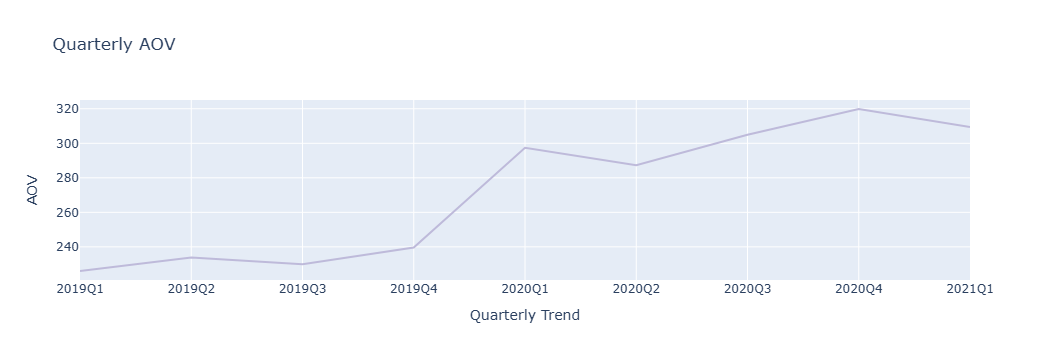

In [77]:
# Graph of AOV of QoQ
fig = px.line(data_frame= aov_quarter, x='QUARTER', y = 'sum',
             labels= {'QUARTER' : 'Quarterly Trend', 
                      'sum' : 'AOV'},
             title= 'Quarterly AOV',
            color_discrete_sequence= ['#BEBADA'])
fig.show()

In [78]:
month_product_sale = df.groupby(['MONTH', 'PRODUCT_NAME'])['USD_PRICE'].mean().reset_index()
month_product_sale

,MONTH,PRODUCT_NAME,USD_PRICE
0,2019-01,27inches 4k gaming monitor,394.130588
1,2019-01,Acer Nitro V Gaming Laptop,766.013333
2,2019-01,JBL Quantum 100 Gaming Headset,22.974048
3,2019-01,Lenovo IdeaPad Gaming 3,932.074286
4,2019-01,Nintendo Switch,161.251799
...,...,...,...
169,2021-02,Dell Gaming Mouse,52.639516
170,2021-02,JBL Quantum 100 Gaming Headset,20.250000
171,2021-02,Lenovo IdeaPad Gaming 3,1173.453333
172,2021-02,Nintendo Switch,164.805450


In [79]:
month_product_sale = pd.pivot_table(month_product_sale, index='MONTH', columns='PRODUCT_NAME', values='USD_PRICE')
month_product_sale

PRODUCT_NAME,27inches 4k gaming monitor,Acer Nitro V Gaming Laptop,Dell Gaming Mouse,JBL Quantum 100 Gaming Headset,Lenovo IdeaPad Gaming 3,Nintendo Switch,Razer Pro Gaming Headset,Sony PlayStation 5 Bundle
MONTH,,,,,,,,
2019-01,394.130588,766.013333,NaN,22.974048,932.074286,161.251799,NaN,1859.301111
2019-02,419.193968,731.880000,NaN,22.918987,1078.302857,159.632138,NaN,1777.589000
2019-03,404.244023,758.100000,NaN,22.155641,1143.386154,156.959920,NaN,1632.419167
2019-04,396.374634,708.986667,NaN,22.466600,1077.168000,158.231477,NaN,1716.841818
2019-05,401.785773,NaN,NaN,22.288000,1144.978182,158.550466,NaN,1839.453529
2019-06,394.338842,790.640000,NaN,22.652222,1110.734167,155.312217,NaN,1699.653636
2019-07,408.560702,768.800000,NaN,22.509936,1058.371333,157.690895,NaN,1706.704000
2019-08,404.092020,648.220000,NaN,22.001701,1168.070000,157.092791,NaN,1656.777143
2019-09,405.466974,798.000000,NaN,22.409053,1028.997647,157.585245,NaN,1712.894667


In [80]:
month_product_sale.style.background_gradient(cmap='RdYlGn').highlight_null('white')

PRODUCT_NAME,27inches 4k gaming monitor,Acer Nitro V Gaming Laptop,Dell Gaming Mouse,JBL Quantum 100 Gaming Headset,Lenovo IdeaPad Gaming 3,Nintendo Switch,Razer Pro Gaming Headset,Sony PlayStation 5 Bundle
MONTH,,,,,,,,
2019-01,394.130588,766.013333,nan,22.974048,932.074286,161.251799,nan,1859.301111
2019-02,419.193968,731.880000,nan,22.918987,1078.302857,159.632138,nan,1777.589000
2019-03,404.244023,758.100000,nan,22.155641,1143.386154,156.959920,nan,1632.419167
2019-04,396.374634,708.986667,nan,22.466600,1077.168000,158.231477,nan,1716.841818
2019-05,401.785773,nan,nan,22.288000,1144.978182,158.550466,nan,1839.453529
2019-06,394.338842,790.640000,nan,22.652222,1110.734167,155.312217,nan,1699.653636
2019-07,408.560702,768.800000,nan,22.509936,1058.371333,157.690895,nan,1706.704000
2019-08,404.092020,648.220000,nan,22.001701,1168.070000,157.092791,nan,1656.777143
2019-09,405.466974,798.000000,nan,22.409053,1028.997647,157.585245,nan,1712.894667


In [81]:
# AOV by region 
order_region = df.groupby(['REGION', 'ORDER_ID'])['USD_PRICE'].sum().reset_index()
order_region

,REGION,ORDER_ID,USD_PRICE
0,APAC,0006d06b98385729,1132.82
1,APAC,000f169e17f4941,168.00
2,APAC,00236994a0b90874,146.25
3,APAC,004602d9c2d12771,1368.45
4,APAC,00740cb808130885,113.84
...,...,...,...
21441,US/Null,fff4592dc6d103537,467.88
21442,X.x,4761e2b30d84080,168.00
21443,X.x,60b221433163208,480.00
21444,X.x,8ced3d2f28d43528,168.00


In [82]:
aov_region = order_region.groupby('REGION')['USD_PRICE'].mean().reset_index()

In [83]:
aov_region.sort_values(by = 'USD_PRICE')

,REGION,USD_PRICE
5,X.x,234.065000
3,North America,245.487954
2,LATAM,270.753433
1,EMEA,281.501593
4,US/Null,288.112542
0,APAC,289.833205


In [84]:
aov_market = df.groupby(['MARKETING_CHANNEL', 'ORDER_ID'])['USD_PRICE'].sum().reset_index()
aov_market = aov_market.groupby('MARKETING_CHANNEL')['USD_PRICE'].mean().reset_index()
aov_market.sort_values(by = 'USD_PRICE')

,MARKETING_CHANNEL,USD_PRICE
2,email,188.659475
3,social media,217.269906
4,unknown,261.829565
1,direct,300.128198
0,affiliate,309.242031


In [85]:
avg_rev = df.groupby('PRODUCT_NAME')['USD_PRICE'].agg(['count', 'mean']).reset_index()
avg_rev.sort_values(by = 'mean')

,PRODUCT_NAME,count,mean
3,JBL Quantum 100 Gaming Headset,4296,22.397968
2,Dell Gaming Mouse,717,51.032036
6,Razer Pro Gaming Headset,7,126.318571
5,Nintendo Switch,10386,159.707072
0,27inches 4k gaming monitor,4688,416.818916
1,Acer Nitro V Gaming Laptop,87,754.726207
4,Lenovo IdeaPad Gaming 3,669,1099.411898
7,Sony PlayStation 5 Bundle,977,1626.656960


**Lifetime Value (LTV)**

In [86]:
df.columns

Index(['USER_ID', 'ORDER_ID', 'PURCHASE_TS', 'SHIP_TS', 'PRODUCT_NAME',
       'PRODUCT_ID', 'USD_PRICE', 'PURCHASE_PLATFORM', 'MARKETING_CHANNEL',
       'ACCOUNT_CREATION_METHOD', 'COUNTRY_CODE', 'REGION', 'QUARTER',
       'MONTH'],
      dtype='object')

In [87]:
ltv = df.groupby('USER_ID')['USD_PRICE'].sum().reset_index()

ltv

,USER_ID,USD_PRICE
0,185974,275.37
1,249061,1041.27
2,266910,168.00
3,268826,392.30
4,292751,168.00
...,...,...
19846,fff8131d,504.00
19847,fff83841,168.00
19848,fff9f549,168.00
19849,fffb781c,480.00


In [88]:
print(f'The overall average LTV is {ltv['USD_PRICE'].mean():.2f}$.')

The overall average LTV is 309.15$.


In [89]:
# LTV by Region 
ltv_region = df.groupby(['REGION', 'USER_ID'])['USD_PRICE'].sum().reset_index()

ltv_region

,REGION,USER_ID,USD_PRICE
0,APAC,292751,168.00
1,APAC,6462644,138.02
2,APAC,6644861,168.00
3,APAC,12159362,0.00
4,APAC,12576301,168.00
...,...,...,...
19592,US/Null,ffffde42,24.00
19593,X.x,002287c5,480.00
19594,X.x,022738f3,168.00
19595,X.x,64a12119,168.00


In [90]:
ltv_region = ltv_region.groupby('REGION')['USD_PRICE'].mean().reset_index()
ltv_region.sort_values(by = 'USD_PRICE')

,REGION,USD_PRICE
5,X.x,234.065000
3,North America,272.987188
2,LATAM,291.979747
1,EMEA,308.354422
4,US/Null,315.091333
0,APAC,317.685045


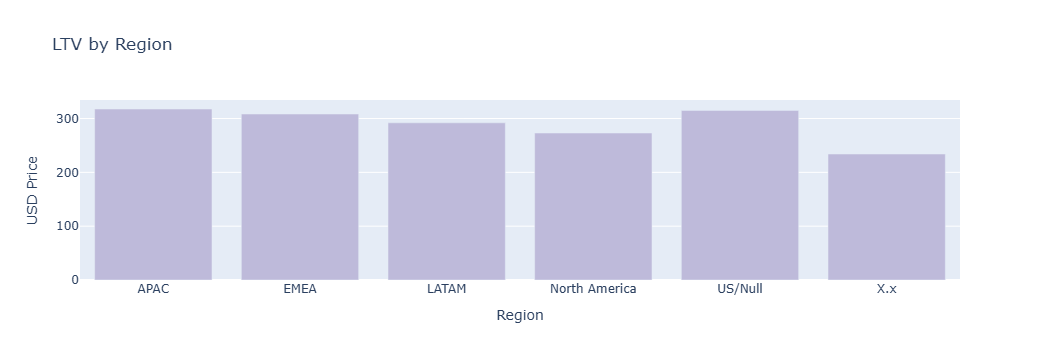

In [91]:
fig = px.bar(data_frame=ltv_region, x= 'REGION', y='USD_PRICE',
             labels = {'REGION': 'Region',
                       'USD_PRICE' : 'USD Price'},
             title = 'LTV by Region',
             color_discrete_sequence= ['#BEBADA'])
fig.show()

In [92]:
df.columns

Index(['USER_ID', 'ORDER_ID', 'PURCHASE_TS', 'SHIP_TS', 'PRODUCT_NAME',
       'PRODUCT_ID', 'USD_PRICE', 'PURCHASE_PLATFORM', 'MARKETING_CHANNEL',
       'ACCOUNT_CREATION_METHOD', 'COUNTRY_CODE', 'REGION', 'QUARTER',
       'MONTH'],
      dtype='object')

In [93]:
# LTV by Marketing Channel
ltv_market = df.groupby(['MARKETING_CHANNEL', 'USER_ID'])['USD_PRICE'].sum().reset_index()

ltv_market

,MARKETING_CHANNEL,USER_ID,USD_PRICE
0,affiliate,8138326,168.00
1,affiliate,31150108,352.37
2,affiliate,36592977,312.04
3,affiliate,42274307,441.86
4,affiliate,42530956,264.58
...,...,...,...
19769,unknown,d77c4210,912.76
19770,unknown,e3f7986,164.69
19771,unknown,f7b54fb7,168.00
19772,unknown,f8a696ff,24.73


In [94]:
ltv_market = ltv_market.groupby(['MARKETING_CHANNEL'])['USD_PRICE'].mean().reset_index()
ltv_market.sort_values(by = 'USD_PRICE')

,MARKETING_CHANNEL,USD_PRICE
2,email,204.776114
3,social media,228.705164
4,unknown,280.096744
1,direct,329.050265
0,affiliate,340.738904


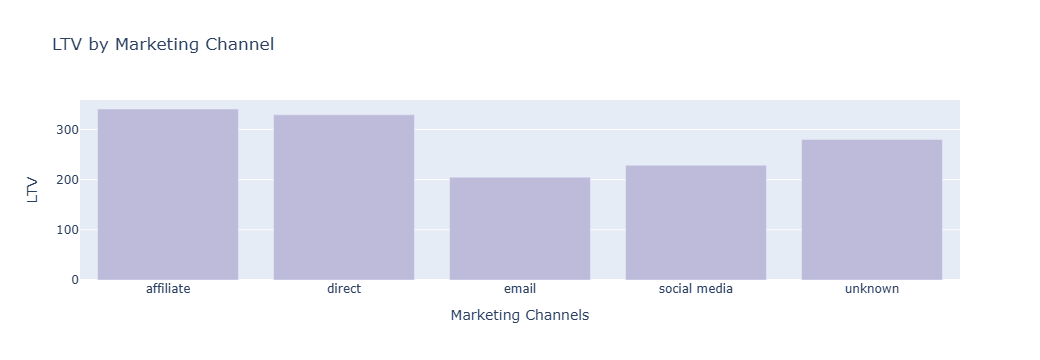

In [95]:
fig = px.bar(data_frame=ltv_market, x='MARKETING_CHANNEL', y='USD_PRICE',
             labels={'MARKETING_CHANNEL' : 'Marketing Channels',
                     'USD_PRICE' : 'LTV'},
             title= 'LTV by Marketing Channel',
             color_discrete_sequence= ['#BEBADA'])
fig.show()

**Sales Growth**

In [96]:
sales_growth = df.groupby('MONTH')['USD_PRICE'].sum().reset_index()
sales_growth

,MONTH,USD_PRICE
0,2019-01,100491.28
1,2019-02,80389.10
2,2019-03,115193.98
3,2019-04,121408.83
4,2019-05,123376.92
5,2019-06,108450.52
6,2019-07,125094.24
7,2019-08,129552.30
8,2019-09,161573.28
9,2019-10,122162.32


In [97]:
sales_growth['MONTH'] = sales_growth['MONTH'].astype(str)
sales_growth.sort_values(by = 'MONTH', inplace=True)
sales_growth

,MONTH,USD_PRICE
0,2019-01,100491.28
1,2019-02,80389.10
2,2019-03,115193.98
3,2019-04,121408.83
4,2019-05,123376.92
5,2019-06,108450.52
6,2019-07,125094.24
7,2019-08,129552.30
8,2019-09,161573.28
9,2019-10,122162.32


In [98]:
sales_growth['SALES_GROWTH'] = sales_growth['USD_PRICE'].pct_change()
sales_growth

,MONTH,USD_PRICE,SALES_GROWTH
0,2019-01,100491.28,NaN
1,2019-02,80389.10,-0.200039
2,2019-03,115193.98,0.432955
3,2019-04,121408.83,0.053951
4,2019-05,123376.92,0.016210
5,2019-06,108450.52,-0.120982
6,2019-07,125094.24,0.153468
7,2019-08,129552.30,0.035638
8,2019-09,161573.28,0.247166
9,2019-10,122162.32,-0.243920


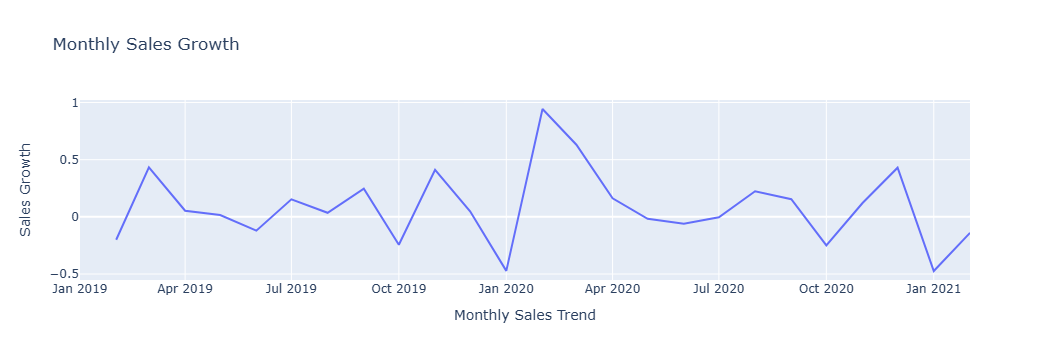

In [99]:
fig = px.line(data_frame=sales_growth, x='MONTH', y='SALES_GROWTH',
              labels={'MONTH' : 'Monthly Sales Trend',
                      'SALES_GROWTH' : 'Sales Growth'},
              title='Monthly Sales Growth')
fig.show()

**Sales Growth Rate**

In [100]:
sales_growth_rate = df.groupby('MONTH')['USD_PRICE'].sum().reset_index()
sales_growth_rate['GROWTH_RATE'] = sales_growth_rate['USD_PRICE'].pct_change() * 100
sales_growth_rate['MONTH'] = sales_growth_rate['MONTH'].astype(str)
sales_growth_rate.sort_values(by = 'MONTH', inplace = True)
sales_growth_rate

,MONTH,USD_PRICE,GROWTH_RATE
0,2019-01,100491.28,NaN
1,2019-02,80389.10,-20.003905
2,2019-03,115193.98,43.295521
3,2019-04,121408.83,5.395117
4,2019-05,123376.92,1.621044
5,2019-06,108450.52,-12.098211
6,2019-07,125094.24,15.346833
7,2019-08,129552.30,3.563761
8,2019-09,161573.28,24.716643
9,2019-10,122162.32,-24.392003


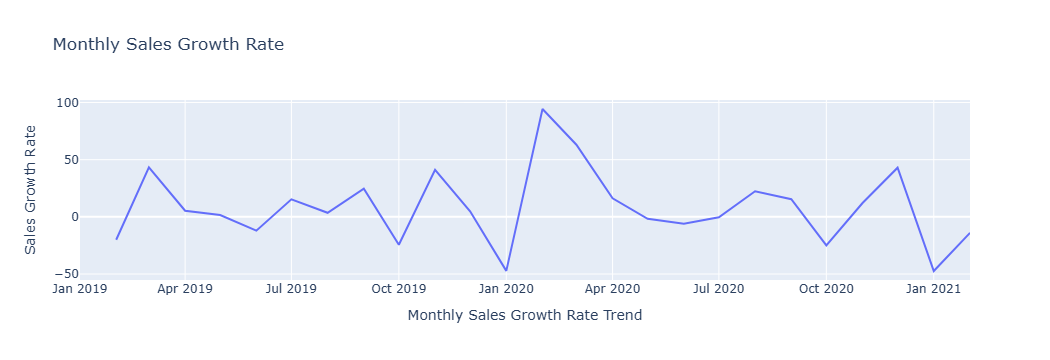

In [101]:
fig = px.line(data_frame=sales_growth_rate, x='MONTH', y='GROWTH_RATE',
              labels = {'MONTH' : 'Monthly Sales Growth Rate Trend',
                        'GROWTH_RATE' : 'Sales Growth Rate'},
              title='Monthly Sales Growth Rate')
fig.show()

In [102]:
monthly_sales = df.resample('ME', on='PURCHASE_TS')['USD_PRICE'].sum().reset_index()
monthly_sales

,PURCHASE_TS,USD_PRICE
0,2019-01-31,100491.28
1,2019-02-28,80389.10
2,2019-03-31,115193.98
3,2019-04-30,121408.83
4,2019-05-31,123376.92
5,2019-06-30,108450.52
6,2019-07-31,125094.24
7,2019-08-31,129552.30
8,2019-09-30,161573.28
9,2019-10-31,122162.32


In [103]:
monthly_sales['GROWTH_RATE'] = monthly_sales['USD_PRICE'].pct_change() * 100
monthly_sales

,PURCHASE_TS,USD_PRICE,GROWTH_RATE
0,2019-01-31,100491.28,NaN
1,2019-02-28,80389.10,-20.003905
2,2019-03-31,115193.98,43.295521
3,2019-04-30,121408.83,5.395117
4,2019-05-31,123376.92,1.621044
5,2019-06-30,108450.52,-12.098211
6,2019-07-31,125094.24,15.346833
7,2019-08-31,129552.30,3.563761
8,2019-09-30,161573.28,24.716643
9,2019-10-31,122162.32,-24.392003


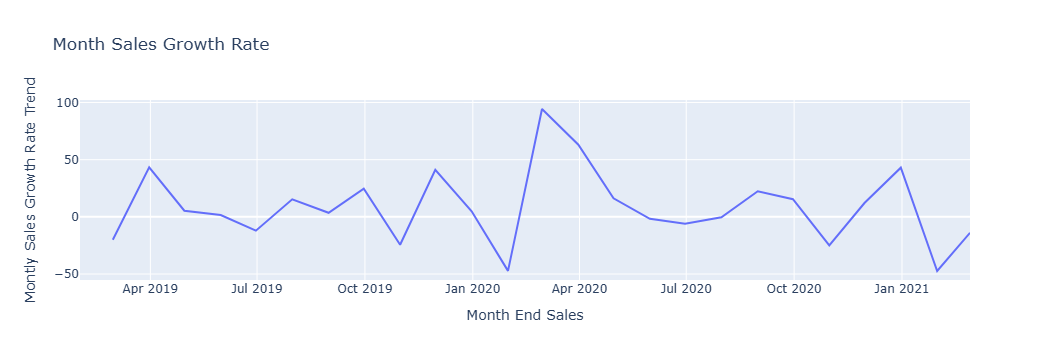

In [104]:
fig = px.line(data_frame=monthly_sales, x='PURCHASE_TS', y='GROWTH_RATE',
              labels={'PURCHASE_TS' : 'Month End Sales',
                      'GROWTH_RATE' : 'Montly Sales Growth Rate Trend'},
              title='Month Sales Growth Rate')
fig.show()

### Customer

**Customer Acquisition Cost (CAC)**

In [105]:
cust_acq = df.sort_values(by = 'PURCHASE_TS').groupby('USER_ID').first().reset_index()
cust_acq

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION,QUARTER,MONTH
0,185974,508f065e0037,2020-12-10,2020-12-11,27inches 4k gaming monitor,891b,275.37,website,direct,desktop,BE,EMEA,2020Q4,2020-12
1,249061,06ca589b49613,2019-11-19,2019-08-01,Lenovo IdeaPad Gaming 3,04ac,1041.27,website,direct,desktop,IT,EMEA,2019Q4,2019-11
2,266910,b735d123e3a16,2019-05-27,2019-05-30,Nintendo Switch,8d0d,168.00,website,direct,desktop,US,US/Null,2019Q2,2019-05
3,268826,2f9f6219a8b17,2020-03-31,2020-04-02,27inches 4k gaming monitor,891b,392.30,website,direct,desktop,US,US/Null,2020Q1,2020-03
4,292751,9ef23f5724b18,2020-10-22,2020-10-23,Nintendo Switch,8d0d,168.00,website,email,desktop,PH,APAC,2020Q4,2020-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19846,fff8131d,22570226b56108108,2020-04-15,2020-04-16,JBL Quantum 100 Gaming Headset,ab0f,24.00,website,direct,desktop,PE,LATAM,2020Q2,2020-04
19847,fff83841,c457f079f08108110,2020-12-10,2020-12-12,Nintendo Switch,8d0d,168.00,website,direct,desktop,US,US/Null,2020Q4,2020-12
19848,fff9f549,fb88e25c9f4108114,2020-04-29,2020-04-30,Nintendo Switch,e682,168.00,website,email,mobile,US,US/Null,2020Q2,2020-04
19849,fffb781c,f2204197256108116,2021-02-26,2021-02-28,27inches 4k gaming monitor,891b,480.00,website,direct,desktop,US,US/Null,2021Q1,2021-02


In [106]:
cust_acq_market = cust_acq.groupby('MARKETING_CHANNEL')['USER_ID'].nunique().reset_index()
cust_acq_market.sort_values(by = 'USER_ID')

,MARKETING_CHANNEL,USER_ID
4,unknown,43
3,social media,304
0,affiliate,648
2,email,2985
1,direct,15794


In [107]:
cust_acq_reg = cust_acq.groupby('REGION')['USER_ID'].nunique().reset_index()
cust_acq_reg.sort_values(by = 'USER_ID')

,REGION,USER_ID
5,X.x,4
3,North America,857
2,LATAM,1148
0,APAC,2331
1,EMEA,5902
4,US/Null,9355


**Customer Retention Rate**

In [108]:
user_order = df.groupby('USER_ID')['ORDER_ID'].nunique()
user_order

USER_ID
185974      1
249061      1
266910      1
268826      1
292751      1
           ..
fff8131d    2
fff83841    1
fff9f549    1
fffb781c    1
ffffde42    1
Name: ORDER_ID, Length: 19851, dtype: int64

In [109]:
returning_users = user_order[user_order > 1].count()
returning_users

np.int64(1857)

In [110]:
total_cust = user_order.count()
total_cust

np.int64(19851)

In [111]:
retention = (returning_users / total_cust) * 100
print(f'Customer Retention Rate (CRR) is {retention:.2f}%')

Customer Retention Rate (CRR) is 9.35%


### Operations

**Delivery Time**

In [112]:
df['DELIVERY_TIME'] = df['SHIP_TS'] - df['PURCHASE_TS']
df.head(2)

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION,QUARTER,MONTH,DELIVERY_TIME
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,US/Null,2020Q4,2020-12,-11 days
1,ee8e5bc2,0002af7a5c6100772,2020-10-01,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE,EMEA,2020Q4,2020-10,-10 days


In [113]:
proper_delivery_time = df[df['DELIVERY_TIME'] >= pd.Timedelta(0)]
proper_delivery_time

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION,QUARTER,MONTH,DELIVERY_TIME
84,6eee6248,01109e7002147835,2020-06-20,2020-06-20,Nintendo Switch,8d0d,152.51,website,direct,desktop,FR,EMEA,2020Q2,2020-06,0 days
318,e31911a4,040f635a51595929,2020-06-12,2020-06-12,JBL Quantum 100 Gaming Headset,ab0f,24.00,website,direct,desktop,US,US/Null,2020Q2,2020-06,0 days
416,821c1406,0551110c7b755483,2020-03-12,2020-03-13,Sony PlayStation 5 Bundle,54ed,1800.00,website,direct,desktop,US,US/Null,2020Q1,2020-03,1 days
985,0cf75a8d,0d06d15e8c48315,2019-11-22,2019-11-23,27inches 4k gaming monitor,891b,312.92,website,direct,desktop,US,US/Null,2019Q4,2019-11,1 days
1151,582cc3ee,0f217c65f0a38617,2019-12-09,2019-12-09,JBL Quantum 100 Gaming Headset,ab0f,24.00,website,direct,desktop,US,US/Null,2019Q4,2019-12,0 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21859,e432cf6f,fff0b6a1e9996384,2019-11-27,2019-11-29,Sony PlayStation 5 Bundle,54ed,1527.06,website,direct,desktop,US,US/Null,2019Q4,2019-11,2 days
21860,f4f11c04,fff4592dc6d103535,2019-12-23,2019-12-26,27inches 4k gaming monitor,891b,467.88,website,direct,desktop,US,US/Null,2019Q4,2019-12,3 days
21861,f4f11c04,fff4592dc6d103537,2019-12-23,2019-12-26,27inches 4k gaming monitor,891b,467.88,website,direct,desktop,US,US/Null,2019Q4,2019-12,3 days
21862,203ce4dd,fff829b061e16171,2021-01-31,2021-02-02,Dell Gaming Mouse,8d4f,67.07,mobile app,direct,desktop,GB,EMEA,2021Q1,2021-01,2 days


In [114]:
print(f'The average delivery time for the orders is {proper_delivery_time['DELIVERY_TIME'].mean()}.')

The average delivery time for the orders is 2 days 01:03:58.241022796.


In [115]:
del_time_region = proper_delivery_time.groupby('REGION')['DELIVERY_TIME'].mean().reset_index()
del_time_region

,REGION,DELIVERY_TIME
0,APAC,2 days 00:18:58.775510204
1,EMEA,2 days 01:01:45.666610140
2,LATAM,1 days 23:56:11.024734982
3,North America,1 days 23:28:54.545454545
4,US/Null,2 days 00:06:47.684464976
5,X.x,2 days 12:00:00


### Save Dataset for dashboard 

In [116]:
df

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,REGION,QUARTER,MONTH,DELIVERY_TIME
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,US/Null,2020Q4,2020-12,-11 days
1,ee8e5bc2,0002af7a5c6100772,2020-10-01,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE,EMEA,2020Q4,2020-10,-10 days
2,9eb4efe0,0002b8350e167074,2020-04-21,2020-02-16,Nintendo Switch,8d0d,151.20,website,direct,desktop,US,US/Null,2020Q2,2020-04,-65 days
3,cac7cbaf,0006d06b98385729,2020-04-07,2020-04-04,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU,APAC,2020Q2,2020-04,-3 days
4,6b0230bc,00097279a2f46150,2020-11-24,2020-08-02,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR,EMEA,2020Q4,2020-11,-114 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21859,e432cf6f,fff0b6a1e9996384,2019-11-27,2019-11-29,Sony PlayStation 5 Bundle,54ed,1527.06,website,direct,desktop,US,US/Null,2019Q4,2019-11,2 days
21860,f4f11c04,fff4592dc6d103535,2019-12-23,2019-12-26,27inches 4k gaming monitor,891b,467.88,website,direct,desktop,US,US/Null,2019Q4,2019-12,3 days
21861,f4f11c04,fff4592dc6d103537,2019-12-23,2019-12-26,27inches 4k gaming monitor,891b,467.88,website,direct,desktop,US,US/Null,2019Q4,2019-12,3 days
21862,203ce4dd,fff829b061e16171,2021-01-31,2021-02-02,Dell Gaming Mouse,8d4f,67.07,mobile app,direct,desktop,GB,EMEA,2021Q1,2021-01,2 days


In [117]:
df.to_excel('Gamesone_Orders_Analyzed_Dataset.xlsx', index=False)